<div style="text-align:center; border-radius:15px 50px; padding:22px; color:white; background-color:#000080; font-family:Pacifico">
<h1 style="color:white; margin:0; font-size:230%">Air Quality Analysis</h1>
<h3 style="color:#c9d4ff; margin-top:10px; font-family:Arial">Hourly Readings, 6 Cities, 2024 &nbsp;|&nbsp; PRG-330 Final Project</h3>
<p style="color:#ffffff; font-family:Arial; font-size:110%; margin-top:16px; margin-bottom:0">
<b>Team:</b> &nbsp; Aishmita &nbsp;&middot;&nbsp; Aaska &nbsp;&middot;&nbsp; Anupam
</p>
</div>

### How we divided the presentation

We kept one continuous air-quality analysis, but divided the presentation so each person has a clear section.

| Part | What it covers | Presented by |
| :---- | :---- | :---- |
| **Part 1** | Introduction, dataset source, file loading, data types and understanding the raw data (Modules 1 to 5) | **Aishmita** |
| **Part 2** | Data cleaning, the missing-CO2 investigation, and the Pandas + NumPy analysis (Modules 6 to 7) | **Aaska** |
| **Part 3** | Applying functions, loops and conditions, the visual analysis, and interpretation (Modules 8 to 9) | **Anupam** |
| **Part 4** | Major findings, limitations and conclusion | **Anupam** |

The notebook stays as one project. The Python concepts from class are shown where they are naturally used in the analysis rather than as separate artificial examples.

## Course concepts used in this project

The concepts from class are **not separate practice examples**. They are used directly in the air-quality analysis below.

| Course concept | Where it is demonstrated in this notebook |
| :--- | :--- |
| **File input / output** | Module 4 loads the CSV with `pd.read_csv()`; Module 6 exports the cleaned data with `to_csv()` |
| **Variables & data types** | Module 5 — `shape`, `columns`, `info()` and converting `Date` from text to a real datetime |
| **Strings** | Module 5/6 — the `Date` column is parsed from text; `City` is a text label used in every grouping |
| **Operators** | Module 6 — arithmetic builds `PM_Total`; comparisons build the high-pollution flag |
| **Conditional statements** | Modules 6 & 8 — `if / elif / else` classifies every hour into an AQI category |
| **Loops** | Modules 6 & 8 — `for` loops apply the classifier row by row and compare selected cities |
| **Functions** | Modules 6 & 8 — `classify_aqi()` and `is_high_pollution()` apply reusable logic |
| **Pandas** | Modules 4–7 — loading, cleaning, grouping, aggregation and correlation |
| **NumPy** | Module 7 — arrays, percentiles/IQR, boolean comparison and correlation verification |
| **Matplotlib** | Module 9 — category, trend and relationship visualizations |

> **Important:** Every concept above is used on the actual project data. We do not add unrelated classroom examples just to show syntax.

# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #000080; overflow:hidden"><b>Part 1: introduction and dataset</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Aishmita</div></div>

### Module 1: project introduction

**What we are doing.** We are analysing one full year (2024) of **hourly air-quality readings** across six cities: Brasilia, Cairo, Dubai, London, New York and Sydney.

**Why we chose this dataset.** Air pollution is a real environmental-health issue, and the dataset is large enough (52,704 rows) to need real data tools rather than eyeballing a spreadsheet. It also has a genuine data-quality problem built in — the `CO2` column is missing for most of the year — which gives us an honest reason to use the cleaning concepts from class instead of pretending the data arrived perfect.

**What we want to find out.**

* which cities have the worst and best air quality, and by how much
* whether air quality follows a predictable pattern across the year
* whether the dataset's worst hours are a general trend or a one-off event
* which pollutants are most strongly linked to the overall Air Quality Index (AQI)
* what to honestly do about a column (CO2) that is missing for most of the year

Because this is a one-year snapshot, our results describe **patterns in this dataset**. They do not prove that any single factor causes air quality to change.

### Module 2: dataset source and description

**Where it came from.**

| | |
| :---- | :---- |
| Name | Air Quality Data (hourly, 6 cities, 2024) |
| File we used | `Air_Quality.csv` |
| Size | 52,704 rows and 10 columns (366 days &times; 24 hours &times; 6 cities, since 2024 is a leap year) |

**What the columns mean.**

* **Date** is the hourly timestamp of the reading
* **City** is one of six cities: Brasilia, Cairo, Dubai, London, New York, Sydney
* **CO** is Carbon Monoxide (ppb)
* **CO2** is Carbon Dioxide (ppm) — only recorded from late October 2024 onward, see Module 6
* **NO2** is Nitrogen Dioxide (ppb)
* **SO2** is Sulfur Dioxide (ppb)
* **O3** is Ozone (ppb)
* **PM2.5** is fine particulate matter (&micro;g/m&sup3;)
* **PM10** is coarse particulate matter (&micro;g/m&sup3;)
* **AQI** is the Air Quality Index — the single EPA-style score the rest of this project is built around

**Why six cities on six different continents?** We picked cities with very different climates and pollution sources on purpose, so the comparison is not just "city A vs city B" but "what kinds of places have worse air."

### Module 3: import libraries

> **Course concepts visible here:** libraries/modules, `import`, pandas, NumPy and Matplotlib.

We use **pandas** for loading, cleaning, grouping and tabular analysis, **NumPy** for numerical array/statistical operations, and **Matplotlib** for visualization.

Other Python concepts from class appear naturally later: variables store analysis results, arithmetic operators build new columns, conditions classify AQI, functions and loops apply that logic across every row, and file output saves the cleaned dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

### Module 4: file input — load the dataset

> **Course concepts:** file input, variables and a pandas DataFrame.

`pd.read_csv()` is the file-input step of the project. It reads the CSV file and turns it into a pandas DataFrame stored in the variable `df`. We use `head()` immediately afterward to confirm that the file loaded correctly and to inspect the raw format before changing anything.

In [2]:
df = pd.read_csv("Air_Quality.csv")
df.head()

,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #191970; overflow:hidden"><b>Part 1 continued: understanding the data</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Aishmita</div></div>

### Module 5: data types and understanding the dataset

> **Course concepts visible here:** variables, strings/text, numeric data types, missing values and DataFrame inspection.

Before cleaning, we inspect the size, column names, data types, missing values and a quick look at how evenly the cities are represented. This is where the **data-type concept** becomes important: `Date` is stored as text, not as a real date, which matters as soon as we want to group by month in Module 6.

In [3]:
# how many rows and columns do we have
df.shape

(52704, 10)

In [4]:
# what are the columns called
df.columns

Index(['Date', 'City', 'CO', 'CO2', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10',
       'AQI'],
      dtype='str')

`info()` is the most useful command here because it shows the data type of every column and
how many values are filled in, both at the same time.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52704 non-null  str    
 1   City    52704 non-null  str    
 2   CO      52704 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     52704 non-null  float64
 5   SO2     52704 non-null  float64
 6   O3      52704 non-null  float64
 7   PM2.5   52704 non-null  float64
 8   PM10    52704 non-null  float64
 9   AQI     52704 non-null  float64
dtypes: float64(8), str(2)
memory usage: 4.0 MB


**What we found.** Every pollutant column and `AQI` is already a proper number (`float64`).
`Date` and `City` are text (`object`). That is a much cleaner starting point than a typical scraped
dataset, but it also means the one real problem in this file is easy to miss if we only skim
`head()` — we have to run `isnull()` to find it.

In [6]:
df.describe()

,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
count,52704.000000,9648.000000,52704.000000,52704.000000,52704.000000,52704.000000,52704.000000,52704.000000
mean,258.258121,462.348259,24.102998,12.569869,60.025729,17.689931,35.643143,41.349339
std,159.589953,33.769009,19.363443,17.266623,38.217348,15.670075,48.444774,26.626149
min,52.000000,434.000000,0.000000,0.000000,0.000000,0.100000,0.100000,4.450000
25%,159.000000,445.000000,9.700000,2.300000,35.000000,6.900000,10.200000,22.800000
50%,213.000000,453.000000,18.900000,5.700000,54.000000,12.500000,18.900000,31.270835
75%,306.000000,467.000000,33.400000,16.800000,78.000000,23.000000,37.500000,57.702089
max,2045.000000,884.000000,165.900000,239.700000,349.000000,129.500000,543.900000,196.633330


**What `describe()` tells us.** `CO2` is the only column where `count` is far lower than the
other columns (9,648 instead of 52,704). Every other numeric column is complete for all 52,704
rows. That single mismatched `count` is the first clue that something is different about `CO2`,
and we dig into exactly what in Module 6.

In [7]:
# how many readings do we have for each city
df["City"].value_counts()

City
Brasilia    8784
Cairo       8784
Dubai       8784
London      8784
New York    8784
Sydney      8784
Name: count, dtype: int64

Every city has exactly **8,784 rows** — 366 days &times; 24 hours. The cities are perfectly
balanced, so any difference we find between them later is not an artifact of one city simply having
more data than another.

In [8]:
# confirm there is exactly one problem column before deciding what to do about it
df.isnull().sum()

Date         0
City         0
CO           0
CO2      43056
NO2          0
SO2          0
O3           0
PM2.5        0
PM10         0
AQI          0
dtype: int64

**What this shows.** `CO2` is the only column with missing values, and it is missing in a
large share of the dataset. Every other column — including `AQI`, the column the rest of this
project is built around — is completely filled in. Aaska investigates *why* `CO2` is missing in
Module 6, rather than assuming it is random.

# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #4B0082; overflow:hidden"><b>Part 2: cleaning the data</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Aaska</div></div>

### Module 6: data cleaning with functions, loops, conditions and operators

> **Course concepts visible here:** type conversion, functions, parameters/return values, `if / elif / else`, `for` loops, comparison checks, arithmetic operators and file output.

From Module 5, the main things to resolve are:

1. `Date` is text, not a real date, so we cannot group by month yet
2. `CO2` is missing for most of the dataset, and we need to know *why* before deciding what to do about it
3. there is no single number yet that tells us, hour by hour, how bad the air actually is in plain language
4. there is no simple way yet to flag hours where *both* particulate measures are high at once

This module uses the concepts from class on a real cleaning task: **type conversion**, a
**function**, **if/elif/else conditions**, a **for loop** and arithmetic calculations.

In [9]:
# Date is stored as text right now — convert it to a real datetime and pull out the month
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

print(df["Date"].dtype, df["Month"].dtype)
df[["Date", "Month"]].head(3)

datetime64[us, UTC] int32


,Date,Month
0,2024-01-01 00:00:00+00:00,1
1,2024-01-01 01:00:00+00:00,1
2,2024-01-01 02:00:00+00:00,1


**Why this matters.** `pd.to_datetime()` turns the text timestamps into real datetime objects,
which is what lets us pull `.dt.month` out directly. Without this conversion, grouping by month in
Module 7 would not be possible at all.

In [10]:
# CO2 coverage by month, for one city, to see whether the gap is random or structural
brasilia_co2 = df[df["City"] == "Brasilia"]
brasilia_co2.groupby("Month")["CO2"].apply(lambda col: col.notnull().sum())

Month
1       0
2       0
3       0
4       0
5       0
6       0
7       0
8       0
9       0
10    144
11    720
12    744
Name: CO2, dtype: int64

**What we found.** `CO2` has **zero** readings from January all the way through most of
October, then becomes almost completely filled in from late October onward. This is a **structural
gap** — a monitoring change that started on a specific date — not a handful of random sensor
dropouts. Filling it in with 0, the column average, or interpolation across the whole year would
fabricate ten months of data that were never actually measured.

In [11]:
# when exactly does usable CO2 data start, and how much of the dataset does it cover
co2_available = df[df["CO2"].notnull()]

print("earliest CO2 reading:", co2_available["Date"].min())
print("latest CO2 reading  :", co2_available["Date"].max())
print("rows with usable CO2:", len(co2_available), f"({len(co2_available) / len(df) * 100:.1f}% of all rows)")
print()
print("average CO2 in that window, by city:")
co2_available.groupby("City")["CO2"].mean().round(1)

earliest CO2 reading: 2024-10-26 00:00:00+00:00
latest CO2 reading  : 2024-12-31 23:00:00+00:00
rows with usable CO2: 9648 (18.3% of all rows)

average CO2 in that window, by city:


City
Brasilia    445.7
Cairo       457.9
Dubai       463.8
London      475.1
New York    488.4
Sydney      443.2
Name: CO2, dtype: float64

**Our decision.** CO2 monitoring started on **26 October 2024**, identically across all six
cities — that shared cutoff date is the signature of a reporting start date, not random missingness.
We do **not** invent CO2 values for January through October. Instead, CO2 is only reported for the
window where it was genuinely measured, and we keep it out of the main year-long city comparison in
Module 7. Every other pollutant and `AQI` is complete for the full year, so those are what drive the
main analysis.

**Classifying AQI needs a function.** A single comparison cannot sort an AQI value into one
of six EPA-style categories at once — that takes a chain of conditions, so we wrote a small function
with `if` / `elif` / `else` in it, the same logic taught in class, applied to real data.

In [12]:
# sorts one AQI value into its EPA-style category
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

In [13]:
# run that function on every row using a loop
categories = []

for aqi in df["AQI"]:
    categories.append(classify_aqi(aqi))

df["AQI Category"] = categories

df["AQI Category"].value_counts()

AQI Category
Good                              37547
Moderate                          12975
Unhealthy for Sensitive Groups     1965
Unhealthy                           217
Name: count, dtype: int64

**How this works step by step.** We make an empty list, go through every value in the `AQI`
column one at a time, pass each one into `classify_aqi()`, and add the answer to the list. When the
loop finishes, the list has one category for every row, so we put it back into the table as a new
column. The vast majority of hours land in **Good** or **Moderate** — the dataset's worst readings
are the exception, not the rule.

In [14]:
# a function that flags hours where both particulate measures are high at once
def is_high_pollution(pm25, pm10, pm25_limit=35, pm10_limit=150):
    return pm25 > pm25_limit and pm10 > pm10_limit

df["High Pollution"] = df.apply(lambda row: is_high_pollution(row["PM2.5"], row["PM10"]), axis=1)

df["High Pollution"].value_counts()

High Pollution
False    50634
True      2070
Name: count, dtype: int64

**Why we built this flag.** `AQI Category` already tells us how bad an hour is overall, but
this flag answers a narrower question: is it specifically the *particulate* pollutants driving that
hour, rather than CO, NO2, SO2 or O3? `and` is a logical operator from class — both conditions have
to be true at once for the flag to be set.

In [15]:
# arithmetic operator: combine the two particulate columns into one total
df["PM_Total"] = df["PM2.5"] + df["PM10"]

df[["PM2.5", "PM10", "PM_Total"]].describe().round(2)

,PM2.5,PM10,PM_Total
count,52704.00,52704.00,52704.00
mean,17.69,35.64,53.33
std,15.67,48.44,62.53
min,0.10,0.10,0.20
25%,6.90,10.20,17.10
50%,12.50,18.90,31.50
75%,23.00,37.50,61.20
max,129.50,543.90,661.70


**Why we calculate this ourselves.** `PM_Total` was not in the original file — we are creating
it, the same way the Daraz-style projects calculate a discount column from two existing price
columns. It gives us one number to look at instead of two whenever we just want a sense of overall
particulate load.

In [16]:
# final check before saving
print(df.isnull().sum())
print()
print("rows:", df.shape[0], " columns:", df.shape[1])
df.dtypes

Date                  0
City                  0
CO                    0
CO2               43056
NO2                   0
SO2                   0
O3                    0
PM2.5                 0
PM10                  0
AQI                   0
Month                 0
AQI Category          0
High Pollution        0
PM_Total              0
dtype: int64

rows: 52704  columns: 14


Date              datetime64[us, UTC]
City                              str
CO                            float64
CO2                           float64
NO2                           float64
SO2                           float64
O3                            float64
PM2.5                         float64
PM10                          float64
AQI                           float64
Month                           int32
AQI Category                      str
High Pollution                   bool
PM_Total                      float64
dtype: object

**Did it work?** Yes. `Date` is now a real datetime, `Month`, `AQI Category`, `High
Pollution` and `PM_Total` are new columns built from the raw data, and `CO2` is the only column with
missing values left — exactly as expected, since we deliberately chose not to invent values for the
ten months it was never measured.

### File output — save the cleaned dataset

> **Course concept visible here:** file output.

After the cleaning checks pass, we export the cleaned DataFrame to a new CSV file. This is a
practical use of file output: the cleaned data, with its new columns, can be reused without
repeating the datetime conversion and classification steps.

In [17]:
# save the cleaned dataset as a reusable project output
df.to_csv("air_quality_cleaned_data.csv", index=False)
print("Cleaned dataset saved: air_quality_cleaned_data.csv")

Cleaned dataset saved: air_quality_cleaned_data.csv


# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #000080; overflow:hidden"><b>Part 2 continued: Pandas + NumPy analysis</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Aaska</div></div>

### Module 7: Pandas + NumPy analysis — answering the project questions

> **Course concepts visible here:** pandas `value_counts()`, `groupby()`, aggregation, filtering and correlation; NumPy arrays, percentiles, IQR, boolean comparisons and `corrcoef()`.

Now that the data is clean, we use pandas and NumPy to answer the questions from Module 1.

In [18]:
# average AQI by city, worst to best
city_summary = df.groupby("City")[["CO", "NO2", "SO2", "O3", "PM2.5", "PM10", "AQI"]].mean().round(2)
city_summary = city_summary.sort_values("AQI", ascending=False)
city_summary

,CO,NO2,SO2,O3,PM2.5,PM10,AQI
City,,,,,,,
Dubai,440.46,39.49,20.31,93.88,41.57,111.04,85.11
Cairo,293.82,32.62,38.29,61.10,23.74,43.42,52.49
New York,283.64,27.80,6.25,52.12,13.36,18.95,32.88
London,187.74,21.80,3.33,49.15,9.99,14.14,27.10
Sydney,122.43,14.17,5.62,46.14,10.94,17.42,25.77
Brasilia,221.45,8.74,1.62,57.76,6.55,8.89,24.75


**How `groupby` works here.** It splits the cleaned dataset into the six cities and
calculates the mean separately inside each group. Dubai sits well above every other city, and
Brasilia sits at the bottom — that gap is the first major finding of the project.

In [19]:
# average AQI by month, across all six cities
monthly_aqi = df.groupby("Month")["AQI"].mean().round(2)
monthly_aqi

Month
1     39.45
2     39.24
3     41.76
4     40.83
5     40.24
6     40.66
7     46.81
8     48.33
9     43.84
10    35.85
11    38.21
12    40.78
Name: AQI, dtype: float64

**What this tells us.** AQI stays in a fairly narrow band all year, but it clearly peaks in
July and August and dips lowest in October. That seasonal swing exists, but it is much smaller than
the gap between the best and worst city above.

In [20]:
# every hour that reaches at least "Unhealthy for Sensitive Groups" (AQI > 100)
high_aqi_df = df[df["AQI"] > 100]
print(f"Hours with AQI > 100: {len(high_aqi_df)} out of {len(df)} ({len(high_aqi_df) / len(df) * 100:.2f}%)")

high_aqi_df[["Date", "City", "AQI", "PM2.5", "PM10"]].sort_values("AQI", ascending=False).head(10)

Hours with AQI > 100: 2182 out of 52704 (4.14%)


,Date,City,AQI,PM2.5,PM10
23092,2024-08-18 04:00:00+00:00,Dubai,196.63333,65.9,391.2
23091,2024-08-18 03:00:00+00:00,Dubai,196.41666,59.3,339.0
23093,2024-08-18 05:00:00+00:00,Dubai,195.93500,70.8,443.3
23090,2024-08-18 02:00:00+00:00,Dubai,195.22168,53.0,314.8
23094,2024-08-18 06:00:00+00:00,Dubai,195.19000,69.6,452.6
23103,2024-08-18 15:00:00+00:00,Dubai,194.91167,52.4,271.0
23104,2024-08-18 16:00:00+00:00,Dubai,194.89668,53.4,278.5
23095,2024-08-18 07:00:00+00:00,Dubai,194.80164,64.7,431.2
23096,2024-08-18 08:00:00+00:00,Dubai,194.41333,60.1,412.6
23102,2024-08-18 14:00:00+00:00,Dubai,194.27502,52.6,276.6


**What jumps out.** Every single one of the ten worst hours in the entire dataset is **Dubai
on 18 August 2024**. It is not spread across the year — it is one event, not a general summer
trend.

In [21]:
# correlation of every pollutant with AQI, strongest first
pollutant_corr = df[["CO", "NO2", "SO2", "O3", "PM2.5", "PM10", "AQI"]].corr()["AQI"].drop("AQI")
pollutant_corr.sort_values(ascending=False).round(3)

PM10     0.846
PM2.5    0.822
CO       0.537
O3       0.453
SO2      0.452
NO2      0.404
Name: AQI, dtype: float64

**What this means.** `PM10` and `PM2.5` are by far the strongest, both clearing the common
|r| > 0.7 "strong correlation" bar. This fits, since AQI is partly *calculated from* particulate
readings in the first place, so this confirms the relationship rather than discovering a new one.
`CO`, `O3`, `SO2` and `NO2` have only a moderate-to-weak relationship with AQI by comparison.

### NumPy numerical analysis

Instead of importing NumPy only for demonstration, we use it directly on the cleaned `AQI` data.
We calculate the **25th percentile (Q1), median (Q2), 75th percentile (Q3), interquartile range
(IQR)**, and a standard 1.5&times;IQR upper threshold, then use a boolean comparison to count how
many hours sit above it.

In [22]:
# NumPy: convert the cleaned AQI column into a numerical array
aqi_array = df["AQI"].to_numpy(dtype=float)

# quartiles and interquartile range
q1, q2, q3 = np.percentile(aqi_array, [25, 50, 75])
iqr = q3 - q1
upper_iqr_threshold = q3 + 1.5 * iqr

# boolean comparison on the NumPy array
high_aqi_count = np.sum(aqi_array > upper_iqr_threshold)

print("records:", aqi_array.size)
print("Q1 (25th percentile):", round(q1, 2))
print("median (50th percentile):", round(q2, 2))
print("Q3 (75th percentile):", round(q3, 2))
print("IQR:", round(iqr, 2))
print("1.5 x IQR upper threshold:", round(upper_iqr_threshold, 2))
print("records above that threshold:", int(high_aqi_count))

records: 52704
Q1 (25th percentile): 22.8
median (50th percentile): 31.27
Q3 (75th percentile): 57.7
IQR: 34.9
1.5 x IQR upper threshold: 110.06
records above that threshold: 1462


**What NumPy adds to the analysis.** The middle 50% of all hourly AQI readings lies between
about **22.8 and 57.7**, with a median of **31.3** — well below the overall mean of **41.3**,
which already tells us the distribution is right-skewed before we ever draw a chart. There are
**1,462** hours above the standard 1.5&times;IQR upper threshold of about **110**. We keep these
high values rather than deleting them, because they describe real recorded pollution events, not
data errors.

In [23]:
# NumPy verification of the strongest relationship: PM10 vs AQI
pm10_array = df["PM10"].to_numpy(dtype=float)

numpy_pm10_aqi_corr = np.corrcoef(pm10_array, aqi_array)[0, 1]
print("NumPy correlation (PM10 vs AQI):", round(float(numpy_pm10_aqi_corr), 3))

NumPy correlation (PM10 vs AQI): 0.846


**Cross-check.** NumPy returns the same correlation of approximately **0.846** for `PM10`
versus `AQI` that pandas gave us above. This confirms the strongest relationship in the dataset is
not the result of one particular pandas command.

In [24]:
# how many hours exceed common single-pollutant thresholds
pm25_array = df["PM2.5"].to_numpy(dtype=float)

unhealthy_aqi_hours = np.sum(aqi_array > 100)
high_pm25_hours = np.sum(pm25_array > 35)
high_pm10_hours = np.sum(pm10_array > 150)

print("hours with AQI > 100  :", unhealthy_aqi_hours)
print("hours with PM2.5 > 35 :", high_pm25_hours)
print("hours with PM10 > 150:", high_pm10_hours)

hours with AQI > 100  : 2182
hours with PM2.5 > 35 : 6655
hours with PM10 > 150: 2110


**Handing off to Anupam.** `city_summary` and `monthly_aqi` are the two tables Anupam turns
into charts in Part 3, and `AQI Category` from Module 6 is what Anupam uses next for the
loop-and-condition comparison in Module 8.

# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #191970; overflow:hidden"><b>Part 3: conditions, loops and visual analysis</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Anupam</div></div>

### Module 8: applying functions, loops and conditions

> **Course concepts visible here:** function calls, `if / else`, lists, `for` loops, variables and pandas filtering.

The project has already used a function, a `for` loop and `if` / `elif` / `else` to classify every
hour's AQI in Module 6. Here we reuse the same ideas to compare a handful of cities directly against
the dataset's overall average.

In [25]:
# use a loop and an if/else condition to compare selected cities against the overall average
cities_to_check = ["Dubai", "London", "Brasilia"]
overall_mean_aqi = df["AQI"].mean()

for city in cities_to_check:
    city_data = df[df["City"] == city]
    city_mean_aqi = city_data["AQI"].mean()
    high_pollution_hours = city_data["High Pollution"].sum()

    if city_mean_aqi > overall_mean_aqi:
        note = "above the overall average"
    else:
        note = "at or below the overall average"

    print(f"{city:10s} | mean AQI {city_mean_aqi:6.2f} | {note:28s} | {high_pollution_hours} high-pollution hours")

Dubai      | mean AQI  85.11 | above the overall average    | 1965 high-pollution hours
London     | mean AQI  27.10 | at or below the overall average | 0 high-pollution hours
Brasilia   | mean AQI  24.75 | at or below the overall average | 0 high-pollution hours


**What this loop does.** The list stores three cities, the `for` loop processes them one at a
time, and the `if` / `else` condition compares each city's mean AQI with the overall mean AQI
computed once outside the loop. This is the same Python logic taught in class, but used directly on
the air-quality analysis rather than in a separate example.

In [26]:
# the AQI category breakdown, as percentages, to see how rare the worst categories really are
category_counts = df["AQI Category"].value_counts()
category_percent = (category_counts / len(df) * 100).round(2)

pd.DataFrame({"hours": category_counts, "percent": category_percent})

,hours,percent
AQI Category,,
Good,37547,71.24
Moderate,12975,24.62
Unhealthy for Sensitive Groups,1965,3.73
Unhealthy,217,0.41


**What this shows.** Almost 95% of all hours in the dataset fall into **Good** or
**Moderate**. The categories that would actually trigger a health advisory — **Unhealthy for
Sensitive Groups** and **Unhealthy** — make up less than 5% of the year combined, which sets up the
next module's finding that those hours are concentrated, not spread evenly.

### Module 9: Matplotlib visualization and interpretation

> **Course concepts visible here:** figure creation, bar charts, horizontal bars, pie chart, line chart, scatter plot, labels/titles and visual interpretation.

Each chart below answers a specific question. We use the chart type that fits the data: bars for
city comparisons, a line for the trend across the year, a pie chart for the AQI-category shares, and
a scatter plot for the strongest pollutant relationship. Every chart is followed by an
interpretation so the notebook explains what the visual means rather than only displaying it.

**1. which city has the worst air quality**

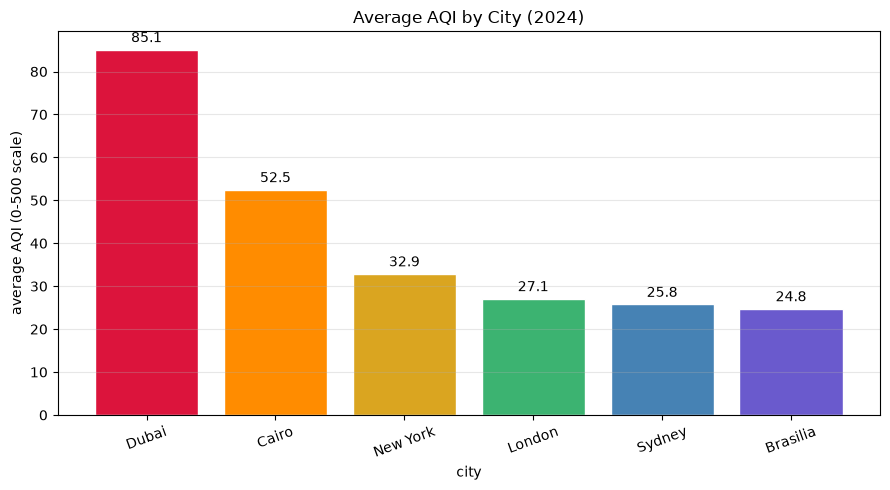

In [27]:
plt.figure(figsize=(9, 5))
bars = plt.bar(city_summary.index, city_summary["AQI"],
                color=["crimson", "darkorange", "goldenrod", "mediumseagreen", "steelblue", "slateblue"],
                edgecolor="white")
plt.bar_label(bars, fmt="%.1f", padding=3)
plt.title("Average AQI by City (2024)")
plt.xlabel("city")
plt.ylabel("average AQI (0-500 scale)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Dubai sits well above the other five cities at an average AQI of 85.1, and Brasilia is the
cleanest at 24.7. A bar chart is appropriate because the question is a direct comparison across six
separate categories (cities).

**2. how AQI moves across the year**

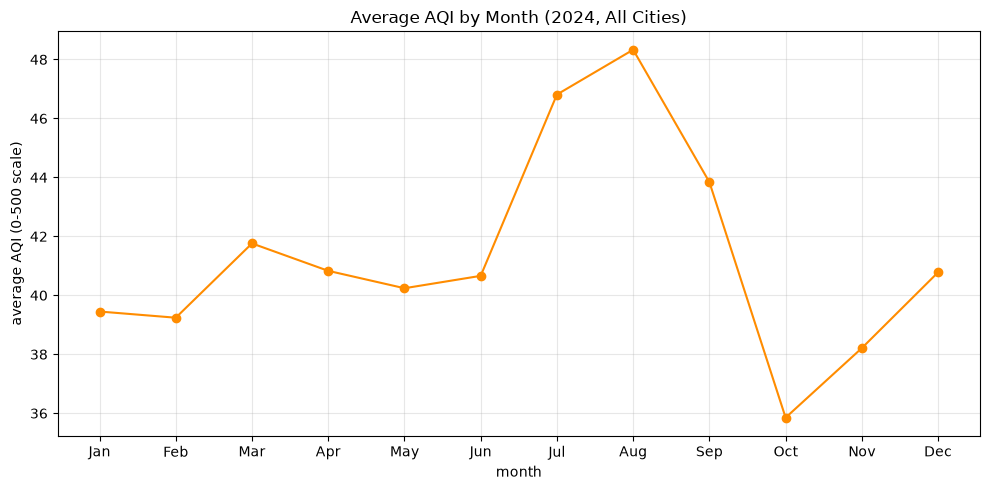

In [28]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))
plt.plot(month_names, monthly_aqi.values, marker="o", color="darkorange")
plt.title("Average AQI by Month (2024, All Cities)")
plt.xlabel("month")
plt.ylabel("average AQI (0-500 scale)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

AQI stays in a fairly narrow band all year, with July and August clearly the worst months and
October the cleanest. We used a line chart because this is a trend over time, not a comparison
between unrelated categories.

**3. how the AQI categories are actually distributed**

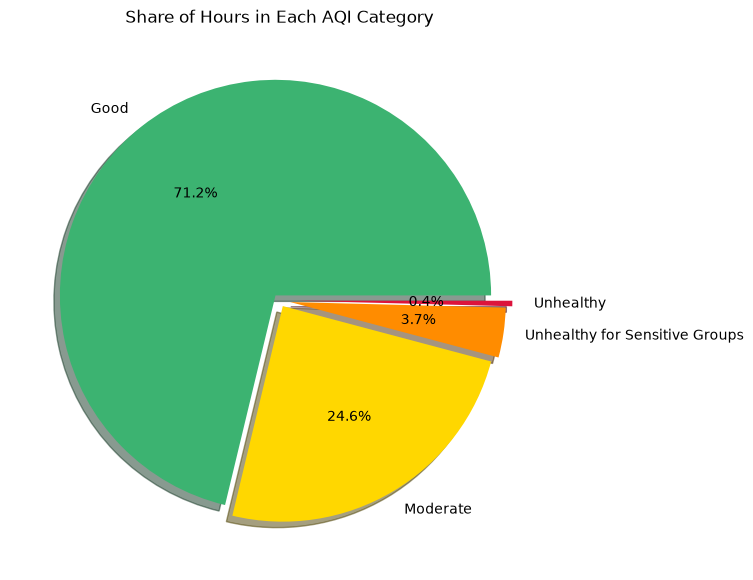

In [29]:
plt.figure(figsize=(7, 7))
plt.pie(category_counts.values,
        labels=category_counts.index,
        colors=["mediumseagreen", "gold", "darkorange", "crimson"],
        autopct="%1.1f%%",
        explode=[0.03, 0.03, 0.05, 0.08],
        shadow=True,
        textprops={"color": "black"})
plt.title("Share of Hours in Each AQI Category")
plt.show()

Almost 95% of all hours fall into Good or Moderate. The pie chart works here because the
categories are mutually exclusive parts of the same 52,704 hours — every hour belongs to exactly
one slice.

**4. does PM10 actually predict AQI**

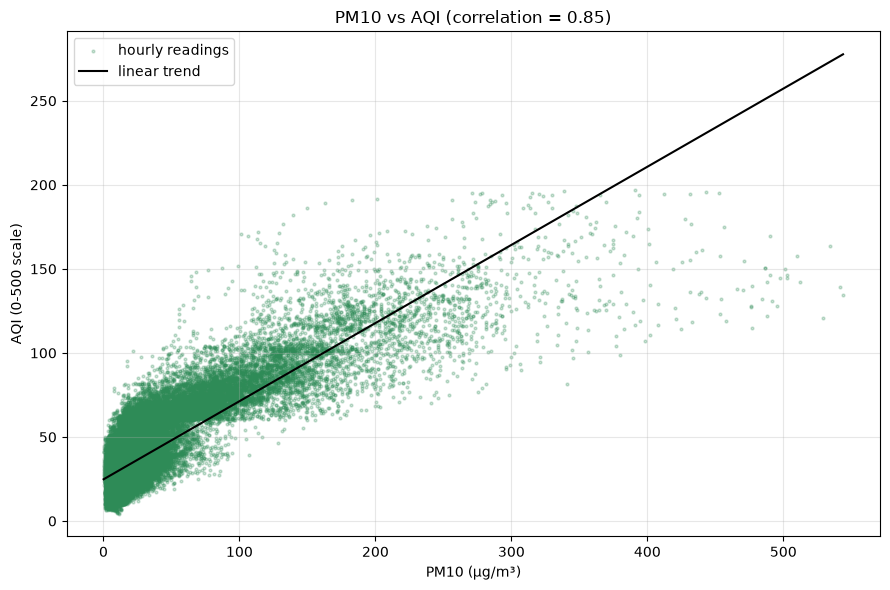

In [30]:
slope, intercept = np.polyfit(df["PM10"], df["AQI"], 1)
trend_x = np.array([df["PM10"].min(), df["PM10"].max()])
trend_y = slope * trend_x + intercept

plt.figure(figsize=(9, 6))
plt.scatter(df["PM10"], df["AQI"], s=4, alpha=0.25, color="seagreen", label="hourly readings")
plt.plot(trend_x, trend_y, color="black", linewidth=1.5, label="linear trend")
plt.title(f"PM10 vs AQI (correlation = {pollutant_corr['PM10']:.2f})")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("AQI (0-500 scale)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The upward pattern is obvious just from the shape of the cloud of points, which backs up the
0.85 correlation calculated with NumPy in Module 7. This is the strongest numerical relationship in
the project.

**5. overall pollutant levels, side by side**

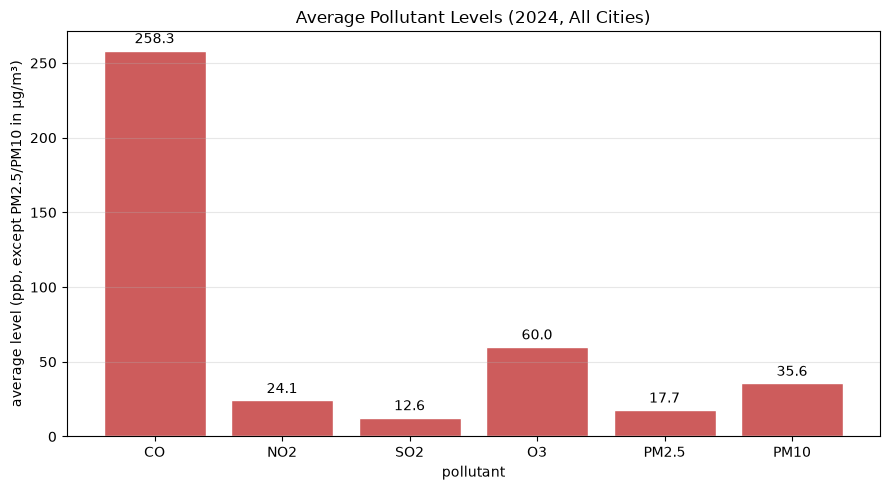

In [31]:
overall_avg = df[["CO", "NO2", "SO2", "O3", "PM2.5", "PM10"]].mean().round(1)

plt.figure(figsize=(9, 5))
bars = plt.bar(overall_avg.index, overall_avg.values, color="indianred", edgecolor="white")
plt.bar_label(bars, fmt="%.1f", padding=3)
plt.title("Average Pollutant Levels (2024, All Cities)")
plt.xlabel("pollutant")
plt.ylabel("average level (ppb, except PM2.5/PM10 in µg/m³)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

CO sits on a completely different scale from the others. That is a unit difference — CO is
simply measured in much larger numbers than PM2.5 or PM10 — not CO being many times more
"present" in the air than the other pollutants.

## Course concept checklist

Before the final findings, this is what the notebook has **actually used on the air-quality data**:

- ✅ **File input / output:** CSV loaded with `pd.read_csv()` and cleaned data exported with `to_csv()`
- ✅ **Variables & data types:** DataFrame variables, strings, floats and `Date` converted from text to datetime
- ✅ **Strings:** `Date` parsed from text; `City` used as a text label in every grouping
- ✅ **Operators:** addition for `PM_Total`, comparisons for the AQI thresholds and the high-pollution flag
- ✅ **Conditions:** `if`, `elif`, `else`
- ✅ **Loops:** `for` loops over real dataset values and selected cities
- ✅ **Functions:** `classify_aqi()` and `is_high_pollution()`, reused in Modules 6 and 8
- ✅ **Pandas:** cleaning, filtering, grouping, aggregation and correlation
- ✅ **NumPy:** arrays, percentiles, IQR, boolean numerical checks and correlation verification
- ✅ **Matplotlib:** multiple chart types with interpretation

This checklist is a map of concepts already demonstrated above; it does not introduce separate
example code.

# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #4B0082; overflow:hidden"><b>Part 4: findings and conclusion</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Anupam</div></div>

## Major findings

The findings below come directly from the cleaned dataset and the outputs above.

**1. Dubai has by far the worst air quality in this dataset; Brasilia has the best.**
Dubai averages an AQI of **85.1**, well into "Moderate" territory and close to "Unhealthy for
Sensitive Groups." Brasilia averages **24.7**, the cleanest of the six, with Sydney (25.8) and
London (27.1) close behind it; Cairo (52.5) and New York (32.9) fall in between. That roughly
60-point gap between the highest and lowest city average is far larger than the month-to-month swing
in Finding 2.

**2. AQI is fairly steady across the year, but clearly peaks in July and August.**
The monthly average never leaves the 36-48 range, but it peaks in July (46.8) and August (48.3) and
dips lowest in October (35.9) — a swing of about 12 points, roughly a fifth of Dubai's full average.

**3. Almost all of the dataset's worst hours trace back to one event.**
2,182 of 52,704 hourly readings (4.14%) exceed AQI 100, but every one of the ten worst hours in the
entire dataset happened in **Dubai on 18 August 2024**. That rules out a general seasonal effect in
favor of a single short-lived pollution event.

**4. Particulate matter is the strongest driver of AQI.**
`PM10` correlates with AQI at **r = 0.85** and `PM2.5` at **r = 0.82** — both comfortably clear the
common |r| > 0.7 "strong correlation" bar, and NumPy's `corrcoef()` reproduces the PM10 figure
independently. CO, O3, SO2 and NO2 all correlate more weakly. This fits, since AQI is partly
*calculated from* particulate readings, so it confirms the relationship rather than discovering a
surprising new one.

**5. The missing CO2 data is a monitoring start date, not random noise.**
81.7% of CO2 readings are missing, but not randomly: every city shows zero CO2 readings before
**26 October 2024** and near-complete coverage afterward. A hard cutoff shared across every city is
the signature of a reporting start date, which is why we kept CO2 out of the main year-long
comparison instead of imputing ten months of invented values.

**6. The vast majority of hours never reach an unhealthy category.**
Almost 95% of all hours fall into "Good" or "Moderate." Only 217 hours in the entire year reach
"Unhealthy," which is consistent with Finding 3 — the worst readings are concentrated in a small
number of events rather than spread evenly across the dataset.

## Limitations

* The dataset is a **one-year snapshot**, so it cannot show how pollution trends change over
  multiple years.
* `CO2` is only usable for about two months (26 Oct – 31 Dec 2024); any CO2-based conclusion is
  scoped to that window only, and is not representative of the full year.
* The dataset does not include information on wildfires, traffic, construction, or weather events
  that could explain *why* individual pollution spikes (like Dubai's 18 August event) happened.
* Because this is observational data, the correlations and city comparisons describe
  **association, not causation** — a city having worse air does not by itself tell us the specific
  cause.

## Summary and conclusion

We analysed 52,704 hourly air-quality readings across six cities for all of 2024, using the Python
concepts from class as part of one continuous analysis: CSV file input/output, datetime conversion,
arithmetic operators, `if`/`elif`/`else` conditions, functions, loops, pandas grouping, **NumPy
numerical analysis**, and Matplotlib visualization.

The clearest result is that **which city you are in matters far more than what month it is**: the
gap between Dubai and Brasilia (about 60 AQI points) dwarfs the seasonal swing between the best and
worst months (about 12 points). The dataset's worst hours are not a seasonal trend at all — they
trace back to a single event in Dubai on 18 August 2024. Particulate matter (PM2.5, PM10) is the
strongest numerical driver of AQI, and the missing CO2 data turned out to be a monitoring start date
rather than a random gap, which is why we reported that limitation honestly instead of guessing at
ten months of numbers.

**Bottom line:** air quality in this dataset is driven far more by *where* you are than *when*, and
the single worst event we found was a one-off spike in Dubai, not a general seasonal pattern.